In [ ]:
import sys
print(sys.version)

3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
from PIL import Image
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import torch.nn as nn
import umap.umap_ as umap
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm


In [ ]:
pwd

'/content'

In [ ]:
# === PARAMÈTRES ===
IMG_DIR = "/content/drive/MyDrive/ENC-PSL/Cours_Traitement_Image_Automatique_Option_ENC_2026/Litt-Jeunesse/output_inference_visages"  # <- adapte ce chemin
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# === TRANSFORMATIONS POUR RESNET ===
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # ResNet attend du 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # Moyennes ImageNet
                         std=[0.229, 0.224, 0.225])
])

# === CHARGER LE MODÈLE RESNET18 SANS LA DERNIÈRE COUCHE ===
resnet = models.resnet18(weights=True)
encoder = nn.Sequential(*list(resnet.children())[:-1])  # Supprime la couche de classification
encoder = encoder.to(DEVICE)
encoder.eval()


In [ ]:
# === CHARGER LES IMAGES ET EXTRAIRE LES EMBEDDINGS ===
features = []
filenames = []

In [ ]:
with torch.no_grad():
    for root, dirs, files in os.walk(IMG_DIR):
        for filename in tqdm(sorted(files)):

            if filename.startswith("._"):
                continue  # ignorer les fichiers macOS

            if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):

                path = os.path.join(root, filename)

                try:
                    image = Image.open(path).convert('RGB')
                except Exception as e:
                    print(f"Erreur avec l'image {filename}: {e}")
                    continue

                tensor = transform(image).unsqueeze(0).to(DEVICE)

                embedding = encoder(tensor)

                features.append(embedding.squeeze().cpu().numpy())
                filenames.append(path)

0it [00:00, ?it/s]
0it [00:00, ?it/s]
100%|██████████| 2/2 [00:01<00:00,  1.25it/s]
0it [00:00, ?it/s]
100%|██████████| 2/2 [00:00<00:00,  3.67it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
100%|██████████| 1/1 [00:00<00:00,  3.63it/s]
0it [00:00, ?it/s]
100%|██████████| 9/9 [00:02<00:00,  3.53it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
100%|██████████| 5/5 [00:01<00:00,  2.84it/s]
0it [00:00, ?it/s]
100%|██████████| 1/1 [00:00<00:00,  2.78it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
100%|██████████| 3/3 [00:00<00:00,  3.68it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
100%|██████████| 5/5 [00:01<00:00,  3.27it/s]
0it [00:00, ?it/s]
100%|██████████| 1/1 [00:00<00:00,  3.29it/s]
0it [00:00, ?it/s]
100%|██████████| 1/1 [00:00<00:00,  3.30it/s]
0it [00:00, ?it/s]
100%|██████████| 3/3 [00:00<00:00,  3.08it/s]


In [ ]:
features[0].shape

(512,)

In [ ]:
# === UMAP SUR LES EMBEDDINGS ===
print("Calcul de UMAP...")
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine')
embedding_2d = reducer.fit_transform(features)

Calcul de UMAP...


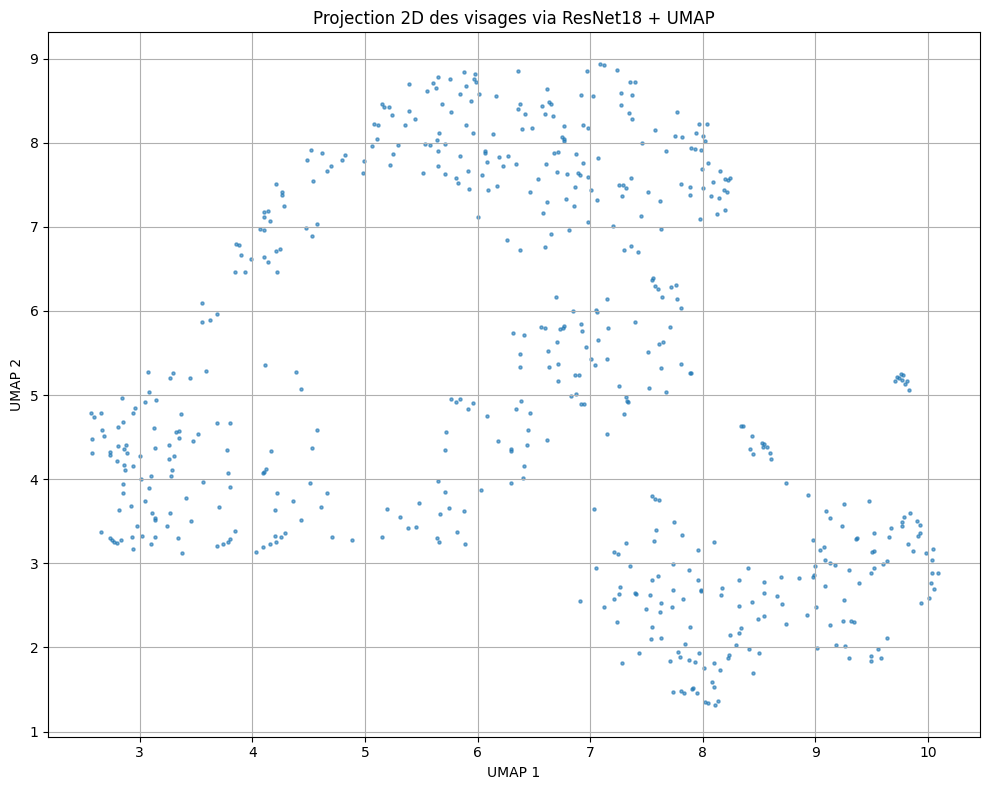

In [ ]:
# === AFFICHAGE SIMPLE ===
plt.figure(figsize=(10, 8))
plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], s=5, alpha=0.6)
plt.title("Projection 2D des visages via ResNet18 + UMAP")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# === ATTRIBUTION DES COULEURS PAR IMAGE ORIGINALE ===
import os
from collections import defaultdict
import matplotlib.cm as cm

def extract_image_id(path):
    """
    Extrait l'ID de l'image originale à partir du nom du fichier.
    Exemple :
    dataset/xxx/000284_face3_cf93.jpg -> 000284
    """
    base = os.path.basename(path)        # 000284_face3_cf93.jpg
    name = os.path.splitext(base)[0]     # 000284_face3_cf93
    return name.split('_')[0]            # 000284


# IDs des images
image_ids = [extract_image_id(f) for f in filenames]

# IDs uniques
unique_ids = sorted(set(image_ids))

# Palette de couleurs
cmap = cm.get_cmap("tab20", len(unique_ids))

# Associer chaque image à une couleur
id_to_color = {img_id: cmap(i) for i, img_id in enumerate(unique_ids)}

# Liste des couleurs pour chaque point
colors = [id_to_color[img_id] for img_id in image_ids]

/tmp/ipykernel_157/638295624.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(unique_ids))


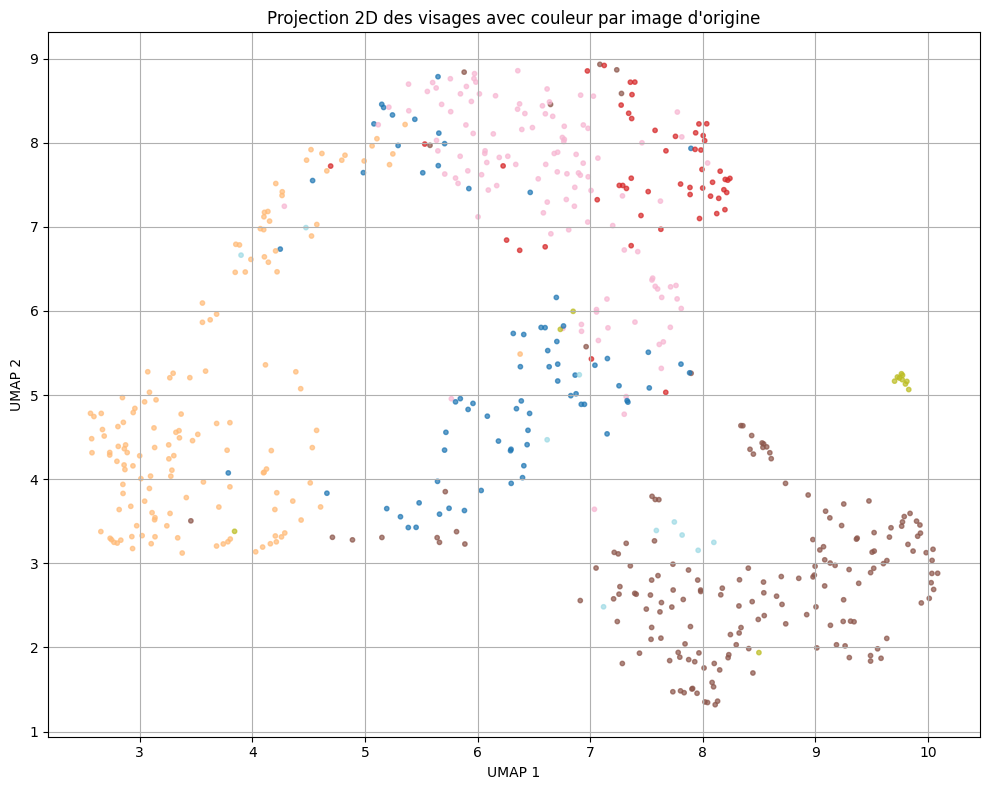

In [ ]:
# === AFFICHAGE AVEC COULEUR PAR IMAGE ===
plt.figure(figsize=(10, 8))
plt.scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    s=10,
    alpha=0.7,
    c=colors
)

plt.title("Projection 2D des visages avec couleur par image d'origine")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(True)
plt.tight_layout()
plt.show()

## Visualisation des visages dans UMAP

In [ ]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

def plot_umap_with_images(embedding_2d, image_paths, zoom=0.3, max_images=500):

    fig, ax = plt.subplots(figsize=(10,10))

    # scatter leggero sotto per struttura globale
    ax.scatter(embedding_2d[:,0], embedding_2d[:,1], s=5, alpha=0.3)

    # ridurre numero immagini per evitare plot troppo pesante
    indices = np.linspace(0, len(image_paths)-1, min(max_images, len(image_paths))).astype(int)

    for i in indices:
        try:
            img = Image.open(image_paths[i])
            img = img.resize((64,64))
            img = np.array(img)

            imagebox = OffsetImage(img, zoom=zoom)
            ab = AnnotationBbox(
                imagebox,
                (embedding_2d[i,0], embedding_2d[i,1]),
                frameon=False
            )

            ax.add_artist(ab)

        except Exception as e:
            print(f"Erreur image {image_paths[i]}: {e}")

    ax.set_title("Projection UMAP avec miniatures des visages")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

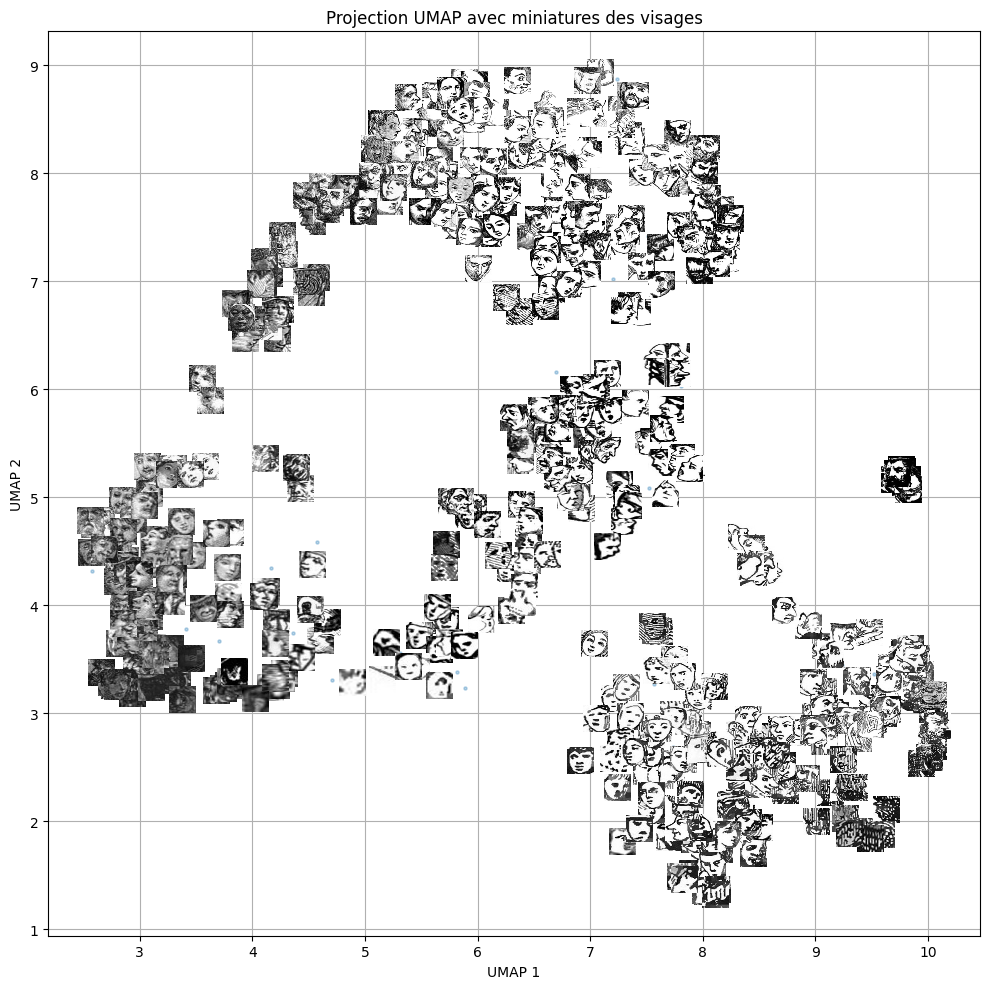

In [ ]:
plot_umap_with_images(embedding_2d, filenames)

## UMAP face map

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

def create_umap_image_map(embedding_2d, image_paths, thumb_size=64, grid_size=40):

    # normalizzazione coordinate tra 0 e 1
    x = embedding_2d[:,0]
    y = embedding_2d[:,1]

    x = (x - x.min()) / (x.max() - x.min())
    y = (y - y.min()) / (y.max() - y.min())

    # canvas finale
    canvas = np.ones((grid_size*thumb_size, grid_size*thumb_size, 3))

    occupied = set()

    for i in range(len(image_paths)):

        gx = int(x[i] * (grid_size-1))
        gy = int(y[i] * (grid_size-1))

        if (gx,gy) in occupied:
            continue

        try:
            img = Image.open(image_paths[i]).convert("RGB")
            img = img.resize((thumb_size, thumb_size))
            img = np.array(img) / 255.0

            x0 = gx * thumb_size
            y0 = gy * thumb_size

            canvas[y0:y0+thumb_size, x0:x0+thumb_size] = img

            occupied.add((gx,gy))

        except:
            continue

    plt.figure(figsize=(12,12))
    plt.imshow(canvas)
    plt.axis("off")
    plt.title("UMAP Face Map")
    plt.show()

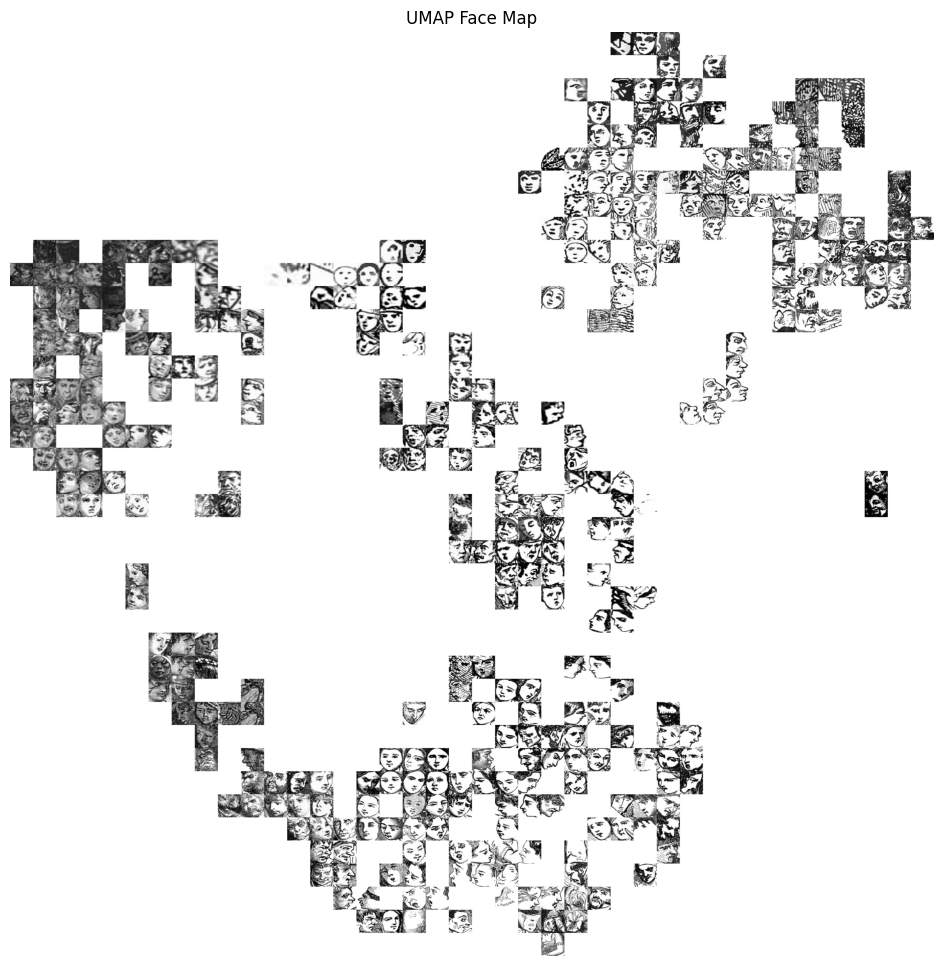

In [ ]:
create_umap_image_map(embedding_2d, filenames)

## UMAP interactive avec hover des titres

In [ ]:
import base64
from io import BytesIO
from PIL import Image
import plotly.express as px
import pandas as pd

def image_to_base64(path, size=64):
    try:
        img = Image.open(path).convert("RGB")
        img = img.resize((size, size))

        buffer = BytesIO()
        img.save(buffer, format="JPEG")

        encoded = base64.b64encode(buffer.getvalue()).decode()
        return f"data:image/jpeg;base64,{encoded}"
    except:
        return None


# convertir images en miniatures encodées
thumbs = [image_to_base64(p) for p in filenames]

df = pd.DataFrame({
    "x": embedding_2d[:,0],
    "y": embedding_2d[:,1],
    "file": filenames,
    "img": thumbs
})

fig = px.scatter(
    df,
    x="x",
    y="y",
    hover_data=["file"],
)

# remplacer le hover par l'image
fig.update_traces(
    marker=dict(size=6, opacity=0.7),
    hovertemplate="""
    <img src="%{customdata[1]}" width="64"><br>
    %{customdata[0]}
    """
)

fig.update_layout(
    title="UMAP interactif des visages",
    width=900,
    height=800
)

fig.show()

## Même chose mais avec les images

In [ ]:
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource
from bokeh.io import output_notebook
import base64
from PIL import Image
from io import BytesIO

output_notebook()

def image_to_base64(path, size=64):
    try:
        img = Image.open(path).convert("RGB")
        img = img.resize((size, size))

        buffer = BytesIO()
        img.save(buffer, format="PNG")

        encoded = base64.b64encode(buffer.getvalue()).decode()
        return f"data:image/png;base64,{encoded}"
    except:
        return None


# miniature
thumbs = [image_to_base64(p) for p in filenames]

source = ColumnDataSource(data=dict(
    x=embedding_2d[:,0],
    y=embedding_2d[:,1],
    imgs=thumbs
))

p = figure(
    width=900,
    height=900,
    title="UMAP Face Constellation",
    tools="pan,wheel_zoom,reset,save"
)

p.image_url(
    url='imgs',
    x='x',
    y='y',
    w=0.5,
    h=0.5,
    anchor="center",
    source=source
)

show(p)

## Autres analyses

In [ ]:
from sklearn.cluster import KMeans
import numpy as np


In [ ]:
X = features
X

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=0, n_init="auto").fit(X)
kmeans.labels_
#kmeans.predict([[0, 0], [12, 3]])
#kmeans.cluster_centers_

array([0, 0, 0, 5, 5, 4, 4, 4, 4, 4, 4, 4, 1, 4, 2, 2, 2, 2, 2, 3, 0, 0,
       0, 3, 2, 2, 3, 3, 5, 1, 1, 5, 4, 5, 0, 5, 2, 1, 2, 2, 3, 2, 1, 0,
       0, 5, 0, 4, 0, 0, 0, 0, 2, 3, 3, 2, 5, 4, 4, 4, 3, 1, 1, 1, 1, 2,
       1, 5, 5, 5, 5, 1, 1, 2, 1, 2, 1, 1, 1, 5, 2, 2, 5, 0, 0, 0, 0, 0,
       0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 5, 5, 5, 5, 5, 5, 5, 2, 1,
       1, 5, 0, 2, 0, 1, 1, 2, 0, 2, 4, 2, 3, 3, 2, 2, 2, 3, 3, 2, 2, 3,
       2, 2, 3, 3, 3, 2, 2, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 4, 2, 2, 2, 2, 3, 2, 4, 3, 2, 3, 3, 3, 2, 2, 3,
       3, 3, 3, 3, 2, 3, 2, 2, 3, 4, 3, 4, 2, 3, 3, 3, 3, 3, 3, 3, 2, 2,
       2, 2, 3, 3, 2, 1, 2, 5, 5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 5, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 5, 5, 1, 1, 1, 2, 2, 1, 3, 4, 2, 2, 2, 1, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 4, 4, 4, 5, 5, 4, 4, 4, 4, 4, 5, 5,
       5, 1, 1, 5, 1, 5, 1, 1, 4, 4, 3, 2, 3, 2, 3, 3, 0, 0, 5, 0, 5, 5,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 4, 0, 0,

In [ ]:
 # max 20 couleurs, boucle ensuite
cm.tab10(kmeans.labels_)


array([[0.58039216, 0.40392157, 0.74117647, 1.        ],
       [0.58039216, 0.40392157, 0.74117647, 1.        ],
       [1.        , 0.49803922, 0.05490196, 1.        ],
       ...,
       [0.17254902, 0.62745098, 0.17254902, 1.        ],
       [0.58039216, 0.40392157, 0.74117647, 1.        ],
       [0.58039216, 0.40392157, 0.74117647, 1.        ]])

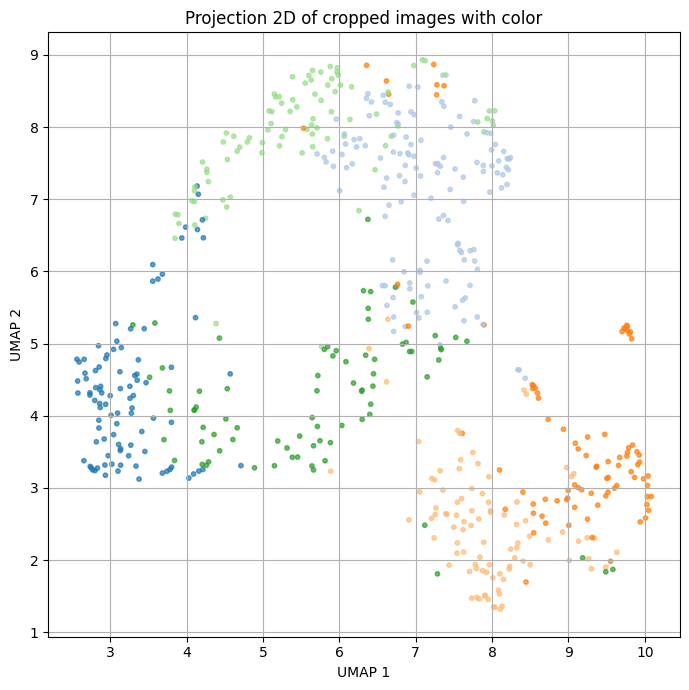

In [ ]:
# === AFFICHAGE AVEC COULEUR PAR IMAGE ===
plt.figure(figsize=(7, 7))
plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], s=10, alpha=0.7, c=cm.tab20(kmeans.labels_))
plt.title("Projection 2D of cropped images with color")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:

import numpy as np

def highlight_cluster(embedding_2d, kmeans, k, alpha=0.7, size_other=10, size_highlight=30):
    """
    Affiche la projection 2D avec une couleur par cluster et met en évidence le cluster `k`.

    Paramètres :
    - embedding_2d : tableau (n, 2), les coordonnées 2D (par ex. UMAP ou t-SNE).
    - kmeans : objet KMeans entraîné, doit avoir un attribut `.labels_`.
    - k : numéro du cluster à mettre en valeur.
    - alpha : transparence des points (défaut : 0.7).
    - size_other : taille des points hors cluster `k` (défaut : 10).
    - size_highlight : taille des points du cluster `k` (défaut : 30).
    """
    labels = kmeans.labels_
    plt.figure(figsize=(7, 7))

    # Afficher tous les points
    plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1],
                s=size_other, alpha=alpha, c=cm.tab20(labels), label='Autres clusters')

    # Mettre en évidence le cluster k avec une bordure noire et un point plus gros
    mask = (labels == k)
    plt.scatter(embedding_2d[mask, 0], embedding_2d[mask, 1],
                s=size_highlight, edgecolors='black', facecolors=cm.tab20(k)[None],
                linewidths=0.6, label=f'Cluster {k}')

    plt.title("Projection 2D des visages (cluster " + str(k) + " en évidence)")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
def highlight_cluster(embedding_2d, kmeans, k, alpha=0.7, size_other=10, size_highlight=30):
    labels = kmeans.labels_
    plt.figure(figsize=(7, 7))

    # Afficher tous les points
    plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1],
                s=size_other, alpha=alpha, c=cm.tab20(labels), label='Autres clusters')

    # Mettre en évidence le cluster k
    mask = (labels == k)
    color = cm.tab20(k)
    plt.scatter(embedding_2d[mask, 0], embedding_2d[mask, 1],
                s=size_highlight, edgecolors='black', facecolors=[color]*np.sum(mask),
                linewidths=0.6, label=f'Cluster {k}')

    plt.title(f"Projection 2D des visages (cluster {k} en évidence)")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


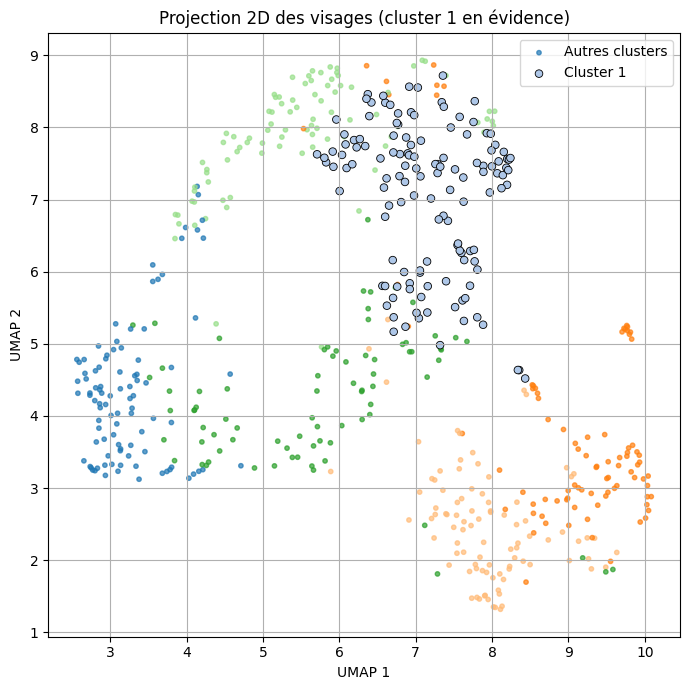

In [ ]:
highlight_cluster(embedding_2d, kmeans, 1, alpha=0.7, size_other=10, size_highlight=30)